##1. Preparar Data

### Leer dataset

In [24]:
import pandas as pd
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV

In [2]:
df_reviews = pd.read_csv('IMDB Dataset.csv')
df_reviews.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
#Desbalancear data (para analizar menos datos)
df_positivo = df_reviews[df_reviews['sentiment'] == 'positive'].sample(n=10000)
df_negativo = df_reviews[df_reviews['sentiment'] == 'negative'].sample(n=5000)

df_reviews_des = pd.concat([df_positivo, df_negativo])

In [4]:
df_reviews_des.value_counts('sentiment')

,count
sentiment,
positive,10000
negative,5000


### Dataset desbalanceada

In [5]:
#Balancear datos
rus = RandomUnderSampler()
df_reviews_bal, df_reviews_bal['sentiment'] = rus.fit_resample(df_reviews_des[['review']], df_reviews_des['sentiment'])
df_reviews_bal.value_counts(['sentiment'])

,count
sentiment,
negative,5000
positive,5000


### Separar datos para train y para test

In [6]:
train, test = train_test_split(df_reviews_bal, test_size=0.3, random_state=42)

In [7]:
train_x, train_y = train['review'], train['sentiment']
test_x, test_y = test['review'], test['sentiment']

## 2. Bag of words

### Transformar datos de texto a datos númericos

In [8]:
tfidf = TfidfVectorizer(stop_words='english')
train_x_vector = tfidf.fit_transform(train_x)
test_x_vector = tfidf.transform(test_x)

In [9]:
train_x_vector

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 620369 stored elements and shape (7000, 44398)>

## 3. Modelos de Machine Learning

### Support Vector Machines

In [26]:
svc = SVC(kernel='linear')
svc.fit(train_x_vector, train_y)

SVC(kernel='linear')

### Decision Tree

In [11]:
dec_tree = DecisionTreeClassifier()
dec_tree.fit(train_x_vector, train_y)

DecisionTreeClassifier()

### Naive Bayes

In [12]:
gnb = GaussianNB()
gnb.fit(train_x_vector.toarray(), train_y)

GaussianNB()

### Logistic Regression

In [13]:
lr = LogisticRegression()
lr.fit(train_x_vector, train_y)

LogisticRegression()

## 4. Evaluación de modelos

### Accuracy score

In [14]:
print(f'Accuracy SVM: {svc.score(test_x_vector, test_y)}')
print(f'Accuracy Decision Tree: {dec_tree.score(test_x_vector, test_y)}')
print(f'Accuracy Naive Bayes: {gnb.score(test_x_vector.toarray(), test_y)}')
print(f'Accuracy Logistic Regression: {lr.score(test_x_vector, test_y)}')

Accuracy SVM: 0.8696666666666667
Accuracy Decision Tree: 0.6996666666666667
Accuracy Naive Bayes: 0.6263333333333333
Accuracy Logistic Regression: 0.868


### F1 Score

In [15]:
print(f'F1 Score SVM: {f1_score(test_y, svc.predict(test_x_vector), labels=["positive", "negative"], average=None)}')
print(f'F1 Score Logistic Regression: {f1_score(test_y, lr.predict(test_x_vector), labels=["positive", "negative"], average=None)}')

F1 Score SVM: [0.86918702 0.87014281]
F1 Score Logistic Regression: [0.86782377 0.86817577]


### Reporte de clasificación

In [16]:
print(f'Classification Report (SVM): \n {classification_report(test_y, svc.predict(test_x_vector), labels=["positive", "negative"])}')

Classification Report (SVM): 
               precision    recall  f1-score   support

    positive       0.85      0.89      0.87      1463
    negative       0.89      0.85      0.87      1537

    accuracy                           0.87      3000
   macro avg       0.87      0.87      0.87      3000
weighted avg       0.87      0.87      0.87      3000



In [18]:
print(f'Classification Report (Logistic Regression): \n {classification_report(test_y, lr.predict(test_x_vector), labels=["positive", "negative"])}')

Classification Report (Logistic Regression): 
               precision    recall  f1-score   support

    positive       0.85      0.89      0.87      1463
    negative       0.89      0.85      0.87      1537

    accuracy                           0.87      3000
   macro avg       0.87      0.87      0.87      3000
weighted avg       0.87      0.87      0.87      3000



### Confusion matrix

In [19]:
print(confusion_matrix(test_y, svc.predict(test_x_vector), labels=["positive", "negative"]))

[[1299  164]
 [ 227 1310]]


In [27]:
cm = confusion_matrix(test_y, svc.predict(test_x_vector), labels=["positive", "negative"])

In [28]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=svc.classes_)

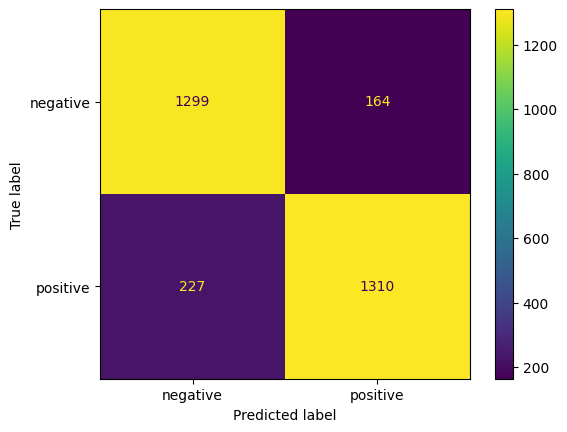

In [32]:
disp.plot()

## 5. Optimización del modelo

### Grid Search CV

In [21]:
parameters = {'C': [1, 4, 8, 16, 32], 'kernel': ['linear', 'rbf']}
svc = SVC()
svc_grid = GridSearchCV(svc, parameters, cv=5)
svc_grid.fit(train_x_vector, train_y)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [1, 4, 8, 16, 32], 'kernel': ['linear', 'rbf']})

In [22]:
print(svc_grid.best_params_)
print(svc_grid.best_estimator_)
print(svc_grid.best_score_)

{'C': 4, 'kernel': 'rbf'}
SVC(C=4)
0.865
